# GO enrichment across cancer types and disruption modalities

Genes are ranked separately for each cancer type and AlphaGenome modality by their median absolute normalized disruption score. GSEA is run separately for every cancer type, modality, and GO category.

In [1]:
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gseapy import prerank

PROJECT_DIR = Path('..').resolve()
CANCER_TYPES = ['BRCA', 'KIRC', 'THCA', 'LGG', 'UCEC']
SCORE_DIR_TEMPLATE = PROJECT_DIR / 'data/alphagenome_scores/patient_tissue_tracks_local_tcga_{cancer_type}'
GENE_COORDS = PROJECT_DIR / 'data/driver_genes_coords/Pancancer.tsv'
TMB_DIR = PROJECT_DIR / 'data/TCGA/tcga_patient_variants_by_cancer'
OUTPUT_DIR = PROJECT_DIR / 'results/tcga_gsea_by_cancer_modality'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_ALPHAGENOME_MODALITIES = ['ATAC', 'RNA_SEQ', 'SPLICE_SITE_USAGE', 'CHIP_TF']
TMB_PSEUDOCOUNT = 1e-6
GSEA_MIN_GENES_PER_MODALITY = 2
GSEA_MIN_GENE_SET_SIZE = 5
GSEA_PERMUTATIONS = 1000
GO_FDR_THRESHOLD = 0.05
GO_GENE_SETS = {
    'Biological Process': 'GO_Biological_Process_2023',
    'Molecular Function': 'GO_Molecular_Function_2023',
    'Cellular Component': 'GO_Cellular_Component_2023',
}

In [2]:
def load_score_rows(score_dir):
    merged_path = score_dir / 'patient_tissue_track_scores.csv'
    if merged_path.exists():
        scores = pd.read_csv(merged_path)
    else:
        patient_files = sorted((score_dir / 'patients').glob('*.csv'))
        if not patient_files:
            raise FileNotFoundError(f'No score files found in {score_dir}')
        scores = pd.concat((pd.read_csv(path) for path in patient_files), ignore_index=True)
    scores = scores[scores['aggregation_type'].eq('L2_DIFF') & scores['scorer'].eq('PATIENT_SINGLE_TRACK_SCORER')]
    scores = scores[(scores['track_strand'].eq(scores['gene_strand'])) | scores['track_strand'].eq('.')]
    return (
        scores[scores['output_type'].isin(SELECTED_ALPHAGENOME_MODALITIES)]
        .groupby(['patient_id', 'gene', 'output_type'], as_index=False)['score']
        .median()
    )


def length_adjusted_scores(scores):
    if len(scores) < 2 or scores['log10_gene_length'].nunique() < 2:
        return scores['tmb_adjusted_score'] - scores['tmb_adjusted_score'].mean()
    slope, intercept = np.polyfit(scores['log10_gene_length'], scores['tmb_adjusted_score'], 1)
    return scores['tmb_adjusted_score'] - (slope * scores['log10_gene_length'] + intercept)


def preprocess_cancer(cancer_type):
    score_dir = Path(str(SCORE_DIR_TEMPLATE).format(cancer_type=cancer_type.lower()))
    scores = load_score_rows(score_dir)
    gene_lengths = pd.read_csv(GENE_COORDS, sep='\t', usecols=['gene', 'length']).drop_duplicates('gene')
    required_genes = set(gene_lengths['gene'])
    completion_files = sorted((score_dir / 'patients').glob('*.completed_patient_genes.tsv'))
    completion_ledger = pd.concat((pd.read_csv(path, sep='\t', dtype=str) for path in completion_files), ignore_index=True)
    patient_gene_counts = completion_ledger[completion_ledger['gene'].isin(required_genes)].groupby('patient_id')['gene'].nunique()
    selected_patients = patient_gene_counts[patient_gene_counts.eq(len(required_genes))].index
    completed_patient_genes = completion_ledger.loc[
        completion_ledger['patient_id'].isin(selected_patients) & completion_ledger['gene'].isin(required_genes),
        ['patient_id', 'gene'],
    ].drop_duplicates()
    scores = scores.merge(completed_patient_genes, on=['patient_id', 'gene'], how='inner')
    tmb = pd.read_csv(TMB_DIR / f'{cancer_type}_tmb.tsv', sep='\t', usecols=['bcr_patient_barcode', 'total_mutations'])
    tmb = tmb.rename(columns={'bcr_patient_barcode': 'patient_id'})
    tmb['tmb'] = np.log1p(pd.to_numeric(tmb['total_mutations'], errors='coerce'))
    gene_lengths['log10_gene_length'] = np.log10(gene_lengths['length'])
    scores = (
        scores.merge(tmb[['patient_id', 'tmb']], on='patient_id', how='left')
        .merge(gene_lengths[['gene', 'log10_gene_length']], on='gene', how='left')
        .dropna(subset=['score', 'tmb', 'log10_gene_length'])
    )
    scores['tmb_adjusted_score'] = scores['score'] / (scores['tmb'] + TMB_PSEUDOCOUNT)
    scores['length_tmb_adjusted_score'] = scores.groupby(['patient_id', 'output_type'], group_keys=False).apply(length_adjusted_scores)
    scores['cancer_type'] = cancer_type
    print(f'{cancer_type}: selected {len(selected_patients):,} patients with completed scoring for all {len(required_genes):,} genes; missing modalities were excluded.')
    return scores


cancer_score_frames = [preprocess_cancer(cancer_type) for cancer_type in CANCER_TYPES]
alphagenome_modality_scores = pd.concat(cancer_score_frames, ignore_index=True)
alphagenome_modality_scores['normalized_score'] = (
    alphagenome_modality_scores.groupby(['cancer_type', 'output_type'])['length_tmb_adjusted_score']
    .transform(lambda scores: (scores - scores.mean()) / (scores.std() + 1e-6))
)
alphagenome_modality_scores.head()

/var/folders/kb/00sgh9j520x459vtmckmbyjw0000gp/T/ipykernel_14141/648244288.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scores['length_tmb_adjusted_score'] = scores.groupby(['patient_id', 'output_type'], group_keys=False).apply(length_adjusted_scores)


BRCA: selected 929 patients with completed scoring for all 633 genes; missing modalities were excluded.


/var/folders/kb/00sgh9j520x459vtmckmbyjw0000gp/T/ipykernel_14141/648244288.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scores['length_tmb_adjusted_score'] = scores.groupby(['patient_id', 'output_type'], group_keys=False).apply(length_adjusted_scores)


KIRC: selected 500 patients with completed scoring for all 633 genes; missing modalities were excluded.


/var/folders/kb/00sgh9j520x459vtmckmbyjw0000gp/T/ipykernel_14141/648244288.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scores['length_tmb_adjusted_score'] = scores.groupby(['patient_id', 'output_type'], group_keys=False).apply(length_adjusted_scores)


...

/var/folders/kb/00sgh9j520x459vtmckmbyjw0000gp/T/ipykernel_14141/648244288.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scores['length_tmb_adjusted_score'] = scores.groupby(['patient_id', 'output_type'], group_keys=False).apply(length_adjusted_scores)


LGG: selected 456 patients with completed scoring for all 633 genes; missing modalities were excluded.


/var/folders/kb/00sgh9j520x459vtmckmbyjw0000gp/T/ipykernel_14141/648244288.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scores['length_tmb_adjusted_score'] = scores.groupby(['patient_id', 'output_type'], group_keys=False).apply(length_adjusted_scores)


UCEC: selected 448 patients with completed scoring for all 633 genes; missing modalities were excluded.


,patient_id,gene,output_type,score,tmb,log10_gene_length,tmb_adjusted_score,length_tmb_adjusted_score,cancer_type,normalized_score
0,TCGA-3C-AAAU,ABCC4,ATAC,0.253551,10.055651,5.449696,0.025215,-0.097534,BRCA,-0.910978
1,TCGA-3C-AAAU,ABCC4,CHIP_TF,12.536345,10.055651,5.449696,1.246696,-80.762119,BRCA,-1.151927
2,TCGA-3C-AAAU,ABCC4,RNA_SEQ,0.107918,10.055651,5.449696,0.010732,-0.100735,BRCA,-0.236898
3,TCGA-3C-AAAU,ABCC4,SPLICE_SITE_USAGE,0.012963,10.055651,5.449696,0.001289,-0.004365,BRCA,-0.701689
4,TCGA-3C-AAAU,ABL1,ATAC,0.209803,10.055651,5.242193,0.020864,-0.095006,BRCA,-0.887372


In [3]:
modality_gene_rankings = (
    alphagenome_modality_scores
    .assign(disruption_score=lambda scores: scores['normalized_score'].abs())
    .groupby(['cancer_type', 'output_type', 'gene'], as_index=False)['disruption_score']
    .median()
    .sort_values(['cancer_type', 'output_type', 'disruption_score'], ascending=[True, True, False])
)

gsea_results = []
for (cancer_type, modality), modality_ranks in modality_gene_rankings.groupby(['cancer_type', 'output_type']):
    ranks = modality_ranks[['gene', 'disruption_score']].sort_values('disruption_score', ascending=False)
    if len(ranks) < GSEA_MIN_GENES_PER_MODALITY:
        continue
    for go_category, gene_set in GO_GENE_SETS.items():
        results = prerank(
            rnk=ranks, gene_sets=gene_set, min_size=GSEA_MIN_GENE_SET_SIZE, max_size=500,
            permutation_num=GSEA_PERMUTATIONS, outdir=None, no_plot=True, seed=0,
        ).res2d.copy()
        if 'Term' not in results.columns:
            results = results.reset_index().rename(columns={'index': 'Term'})
        results['cancer_type'] = cancer_type
        results['modality'] = modality
        results['go_category'] = go_category
        gsea_results.append(results)

gsea_results = pd.concat(gsea_results, ignore_index=True) if gsea_results else pd.DataFrame()
gsea_results.head()

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cancer_type,modality,go_category
0,prerank,Negative Regulation Of Transforming Growth Fac...,0.859052,2.323422,0.000000,0.010891,0.009,4/7,1.90%,SIN3A;ING1;BCL9L;PRDM16,BRCA,ATAC,Biological Process
1,prerank,Negative Regulation Of Transmembrane Receptor ...,0.730342,2.203086,0.000000,0.039207,0.056,4/10,1.90%,SIN3A;ING1;BCL9L;PRDM16,BRCA,ATAC,Biological Process
2,prerank,Regulation Of Transforming Growth Factor Beta ...,0.578123,2.166002,0.000000,0.041385,0.087,7/20,6.95%,SIN3A;ING1;BCL9L;STK11;PRDM16;HSP90AB1;SMAD3,BRCA,ATAC,Biological Process
3,prerank,Regulation Of Cold-Induced Thermogenesis (GO:0...,0.606471,2.130369,0.000000,0.047647,0.129,12/16,28.44%,STK11;PRDM16;ZBTB7B;RB1;STAT6;EPAS1;GNAS;TSHR;...,BRCA,ATAC,Biological Process
4,prerank,Negative Regulation Of Multicellular Organisma...,0.540468,1.988943,0.002225,0.219995,0.491,6/19,8.37%,SIN3A;ING1;STK11;GSK3B;RB1;EGFR,BRCA,ATAC,Biological Process


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cancer_type,modality,go_category,nominal_p_value,nes,bh_adjusted_p_value
0,prerank,Negative Regulation Of Transforming Growth Fac...,0.859052,2.323422,0.0,0.010891,0.009,4/7,1.90%,SIN3A;ING1;BCL9L;PRDM16,BRCA,ATAC,Biological Process,0.0,2.323422,0.0
1,prerank,Negative Regulation Of Transmembrane Receptor ...,0.730342,2.203086,0.0,0.039207,0.056,4/10,1.90%,SIN3A;ING1;BCL9L;PRDM16,BRCA,ATAC,Biological Process,0.0,2.203086,0.0
2,prerank,Regulation Of Transforming Growth Factor Beta ...,0.578123,2.166002,0.0,0.041385,0.087,7/20,6.95%,SIN3A;ING1;BCL9L;STK11;PRDM16;HSP90AB1;SMAD3,BRCA,ATAC,Biological Process,0.0,2.166002,0.0
3,prerank,Regulation Of Cold-Induced Thermogenesis (GO:0...,0.606471,2.130369,0.0,0.047647,0.129,12/16,28.44%,STK11;PRDM16;ZBTB7B;RB1;STAT6;EPAS1;GNAS;TSHR;...,BRCA,ATAC,Biological Process,0.0,2.130369,0.0
6,prerank,Regulation Of Protein Localization To Nucleus ...,0.567635,1.956901,0.0,0.221395,0.605,8/15,16.11%,SIN3A;GSK3B;JAK1;TCF7L2;CTNNA1;WWTR1;TPR;KAT7,BRCA,ATAC,Biological Process,0.0,1.956901,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8512,prerank,Tau Protein Binding (GO:0048156),0.902803,2.076062,0.0,0.069878,0.350,2/7,1.42%,HSP90AB1;HSP90AA1,LGG,RNA_SEQ,Molecular Function,0.0,2.076062,0.0
12871,prerank,RNA Binding (GO:0003723),0.574379,2.494320,0.0,0.000000,0.000,21/76,8.06%,HSP90AB1;RPS3A;TMSB4X;HLA-A;CTNNA1;PABPC1;HSP9...,THCA,RNA_SEQ,Molecular Function,0.0,2.494320,0.0
12872,prerank,Disordered Domain Specific Binding (GO:0097718),0.825228,2.210757,0.0,0.025808,0.050,3/8,3.00%,HSP90AB1;HSP90AA1;CLTC,THCA,RNA_SEQ,Molecular Function,0.0,2.210757,0.0
12873,prerank,Tau Protein Binding (GO:0048156),0.821678,2.079030,0.0,0.077683,0.204,2/7,2.05%,HSP90AB1;HSP90AA1,THCA,RNA_SEQ,Molecular Function,0.0,2.079030,0.0


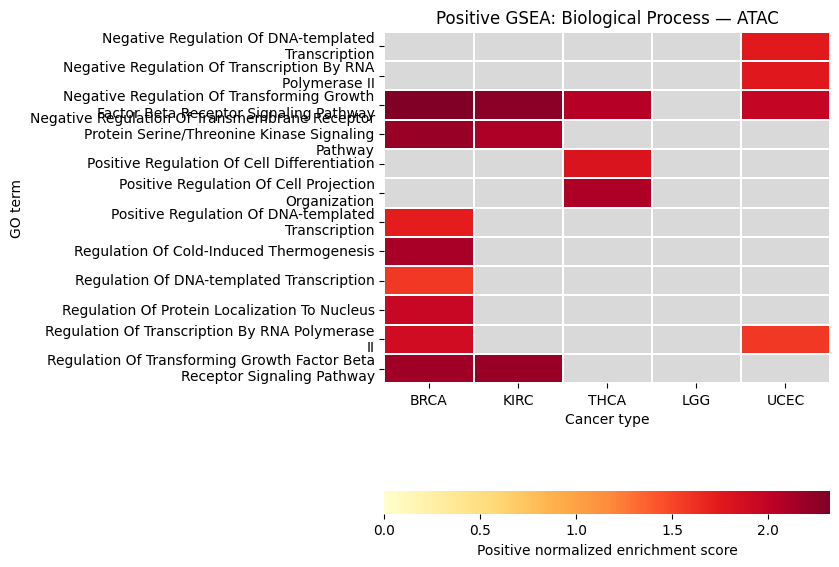

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/positive_gsea_biological_process_atac_by_cancer.png


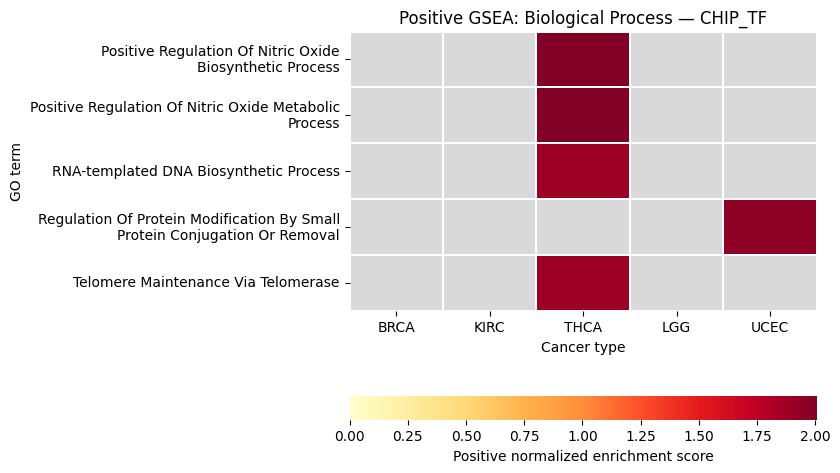

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/positive_gsea_biological_process_chip_tf_by_cancer.png


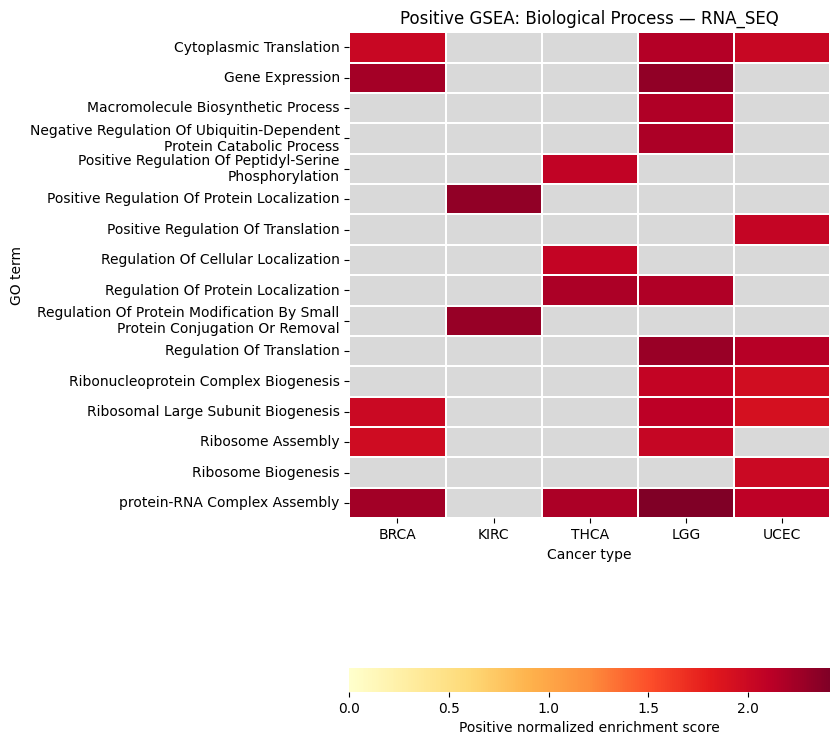

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/positive_gsea_biological_process_rna_seq_by_cancer.png


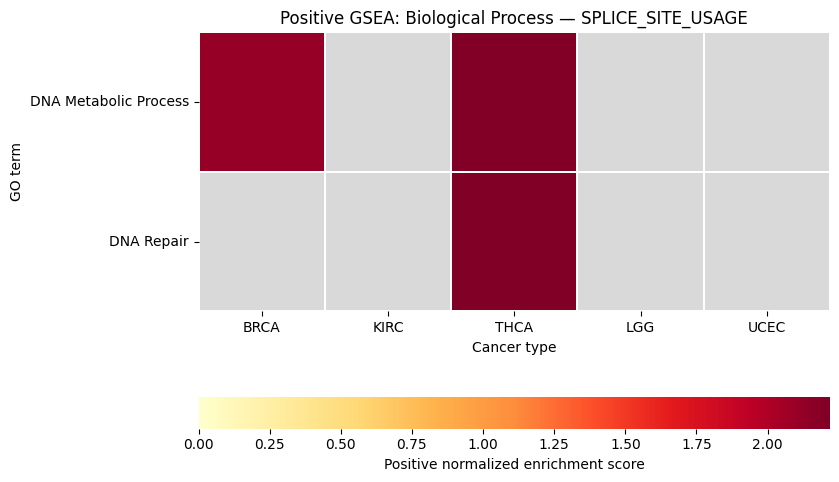

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/positive_gsea_biological_process_splice_site_usage_by_cancer.png


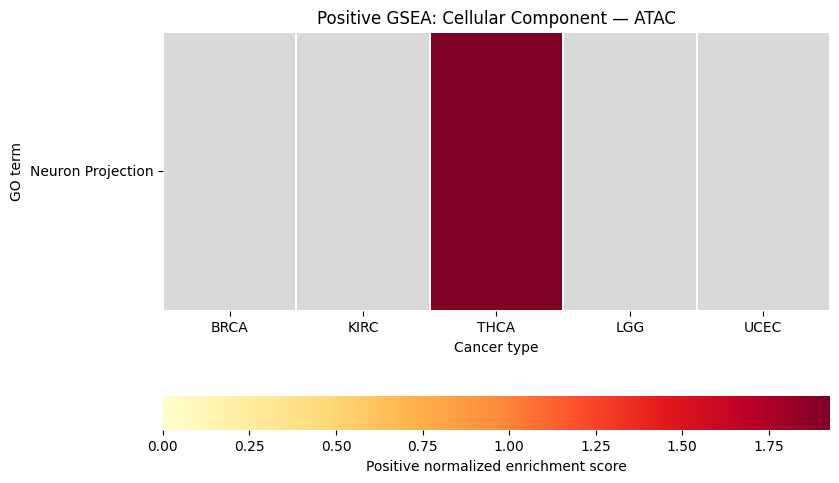

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/positive_gsea_cellular_component_atac_by_cancer.png


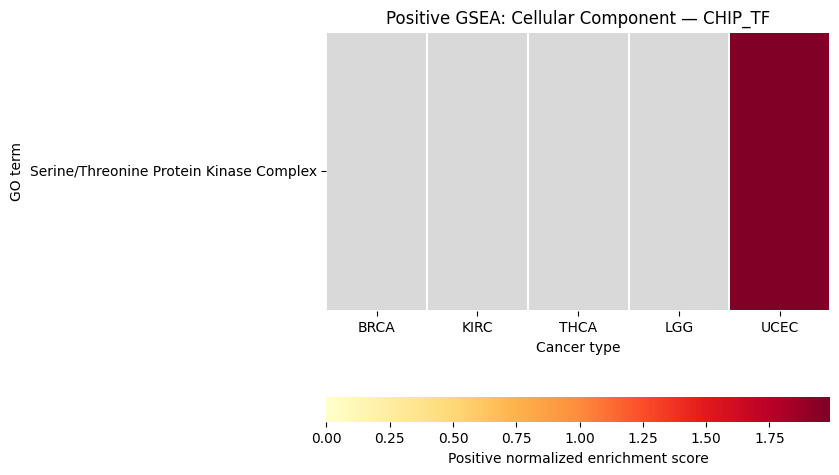

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/positive_gsea_cellular_component_chip_tf_by_cancer.png


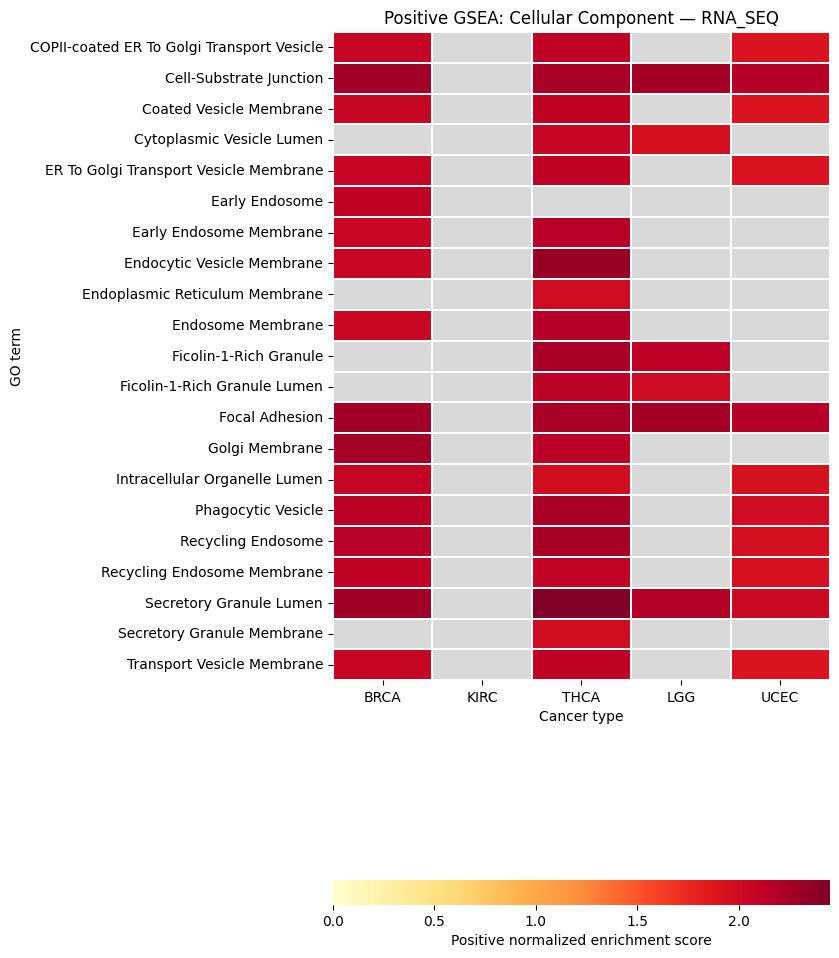

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/positive_gsea_cellular_component_rna_seq_by_cancer.png


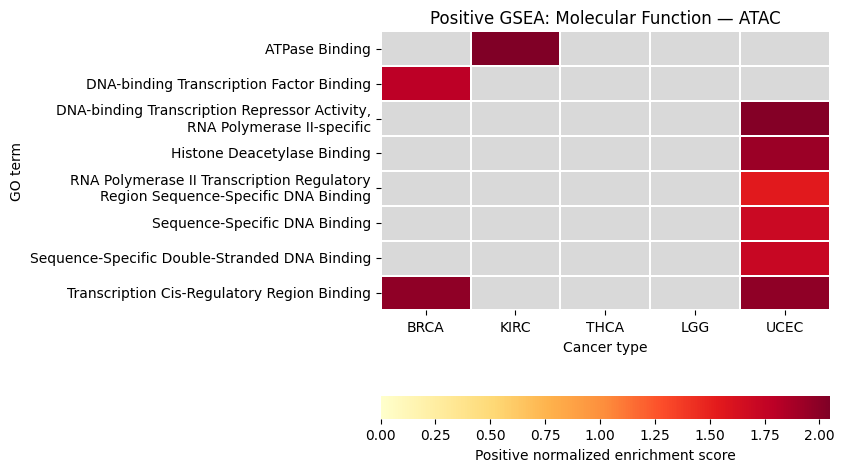

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/positive_gsea_molecular_function_atac_by_cancer.png


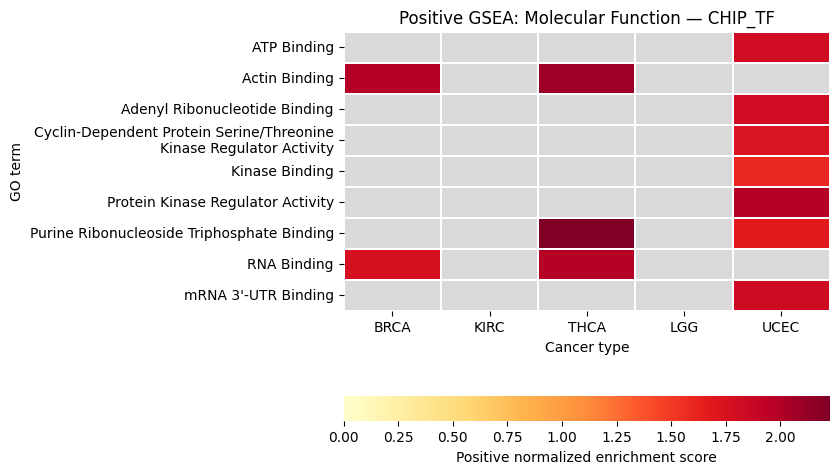

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/positive_gsea_molecular_function_chip_tf_by_cancer.png


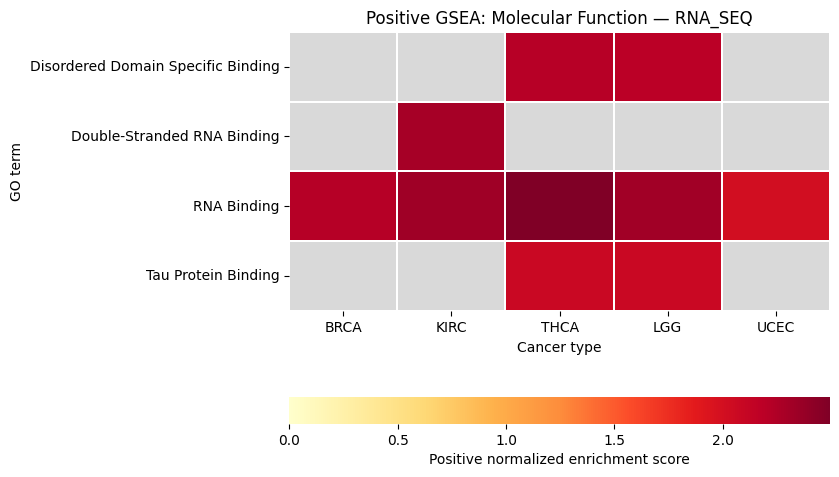

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/positive_gsea_molecular_function_rna_seq_by_cancer.png


In [4]:
def benjamini_hochberg(p_values):
    ranked = p_values.sort_values()
    adjusted = (ranked * len(ranked) / np.arange(1, len(ranked) + 1)).clip(upper=1)
    return adjusted.iloc[::-1].cummin().iloc[::-1].reindex(p_values.index)


if gsea_results.empty:
    print('No GSEA results were returned.')
else:
    gsea_results['nominal_p_value'] = pd.to_numeric(gsea_results['NOM p-val'], errors='coerce')
    gsea_results['nes'] = pd.to_numeric(gsea_results['NES'], errors='coerce')
    gsea_results['bh_adjusted_p_value'] = (
        gsea_results.groupby(['cancer_type', 'modality', 'go_category'])['nominal_p_value']
        .transform(benjamini_hochberg)
    )
    positive_significant = gsea_results[
        gsea_results['bh_adjusted_p_value'].lt(GO_FDR_THRESHOLD) & gsea_results['nes'].gt(0)
    ].copy()
    if positive_significant.empty:
        print('No significantly positive GO enrichments were found.')
    else:
        display(positive_significant.sort_values(['go_category', 'modality', 'cancer_type', 'bh_adjusted_p_value']))
        for (go_category, modality), category_results in gsea_results.groupby(['go_category', 'modality']):
            selected_terms = positive_significant.loc[
                positive_significant['go_category'].eq(go_category) & positive_significant['modality'].eq(modality),
                'Term',
            ].unique()
            if not len(selected_terms):
                continue
            heatmap_results = category_results[category_results['Term'].isin(selected_terms)]
            enrichment_df = heatmap_results.pivot_table(index='Term', columns='cancer_type', values='nes', aggfunc='max').reindex(columns=CANCER_TYPES)
            adjusted_p_values = heatmap_results.pivot_table(index='Term', columns='cancer_type', values='bh_adjusted_p_value', aggfunc='min').reindex(columns=CANCER_TYPES)
            mask = adjusted_p_values.ge(GO_FDR_THRESHOLD) | adjusted_p_values.isna() | enrichment_df.le(0)
            fig, ax = plt.subplots(figsize=(max(8, 1.7 * len(CANCER_TYPES)), max(5, 0.5 * len(enrichment_df))))
            ax.set_facecolor('#D9D9D9')
            sns.heatmap(enrichment_df, mask=mask, cmap='YlOrRd', vmin=0, linewidths=0.25, linecolor='white', cbar_kws={'label': 'Positive normalized enrichment score', 'orientation': 'horizontal', 'pad': 0.2}, ax=ax)
            ax.set_yticklabels([fill(term.split(' (')[0], width=45) for term in enrichment_df.index], rotation=0)
            ax.set_xlabel('Cancer type')
            ax.set_ylabel('GO term')
            ax.set_title(f'Positive GSEA: {go_category} — {modality}')
            fig.tight_layout()
            output_name = 'positive_gsea_' + go_category.lower().replace(' ', '_') + '_' + modality.lower() + '_by_cancer.png'
            output_plot = OUTPUT_DIR / output_name
            fig.savefig(output_plot, dpi=300, bbox_inches='tight')
            plt.show()
            print(output_plot)

## Positive GO enrichment shared across cancer types

Only terms with significant positive enrichment in more than one cancer type are shown.

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cancer_type,modality,go_category,nominal_p_value,nes,bh_adjusted_p_value,n_significant_cancer_types
0,prerank,Negative Regulation Of Transforming Growth Fac...,0.859052,2.323422,0.0,0.010891,0.009,4/7,1.90%,SIN3A;ING1;BCL9L;PRDM16,BRCA,ATAC,Biological Process,0.0,2.323422,0.0,4
29,prerank,Negative Regulation Of Transforming Growth Fac...,0.805622,2.267005,0.0,0.096405,0.081,4/7,2.53%,SIN3A;BCL9L;PRDM16;ING1,KIRC,ATAC,Biological Process,0.0,2.267005,0.0,4
50,prerank,Negative Regulation Of Transforming Growth Fac...,0.789559,2.065311,0.0,0.167302,0.227,5/7,12.95%,PRDM16;BCL9L;ING1;SIN3A;FBN2,THCA,ATAC,Biological Process,0.0,2.065311,0.0,4
78,prerank,Negative Regulation Of Transforming Growth Fac...,0.816236,1.971216,0.0,0.113233,0.165,4/7,2.21%,ING1;SIN3A;BCL9L;PRDM16,UCEC,ATAC,Biological Process,0.0,1.971216,0.0,4
1,prerank,Negative Regulation Of Transmembrane Receptor ...,0.730342,2.203086,0.0,0.039207,0.056,4/10,1.90%,SIN3A;ING1;BCL9L;PRDM16,BRCA,ATAC,Biological Process,0.0,2.203086,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,prerank,RNA Binding (GO:0003723),0.758565,2.323254,0.0,0.007541,0.008,23/76,8.06%,RPL5;TMSB4X;HSP90AB1;RPL10;RPS3A;HSP90AA1;EIF4...,LGG,RNA_SEQ,Molecular Function,0.0,2.323254,0.0,5
56,prerank,RNA Binding (GO:0003723),0.574379,2.494320,0.0,0.000000,0.000,21/76,8.06%,HSP90AB1;RPS3A;TMSB4X;HLA-A;CTNNA1;PABPC1;HSP9...,THCA,RNA_SEQ,Molecular Function,0.0,2.494320,0.0,5
87,prerank,RNA Binding (GO:0003723),0.720123,2.008101,0.0,0.084839,0.068,19/76,5.69%,RPL10;RPL5;RPS3A;TMSB4X;HSP90AB1;MYH9;EIF3E;NP...,UCEC,RNA_SEQ,Molecular Function,0.0,2.008101,0.0,5
43,prerank,Tau Protein Binding (GO:0048156),0.902803,2.076062,0.0,0.069878,0.350,2/7,1.42%,HSP90AB1;HSP90AA1,LGG,RNA_SEQ,Molecular Function,0.0,2.076062,0.0,2


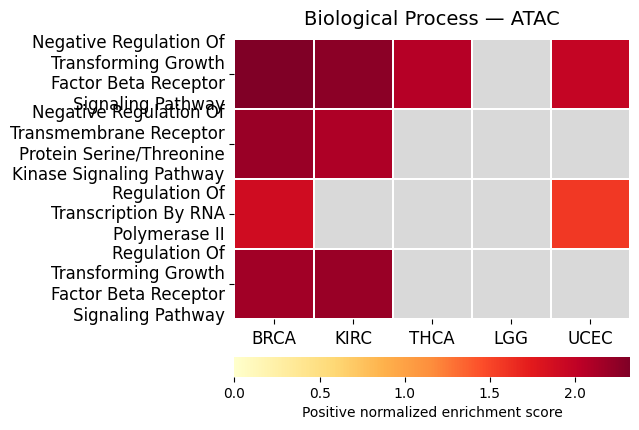

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/shared_positive_gsea_biological_process_atac_by_cancer.png


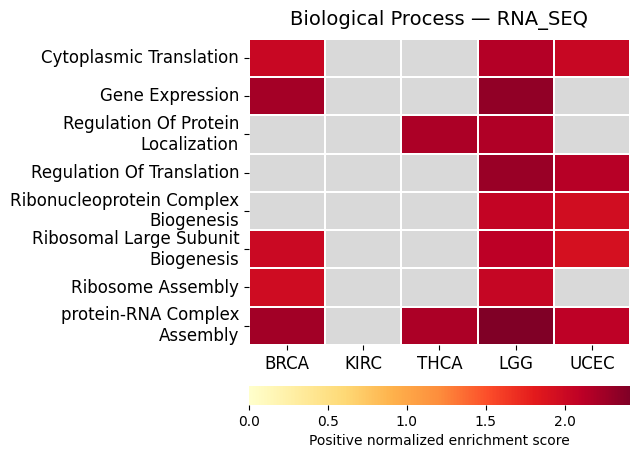

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/shared_positive_gsea_biological_process_rna_seq_by_cancer.png


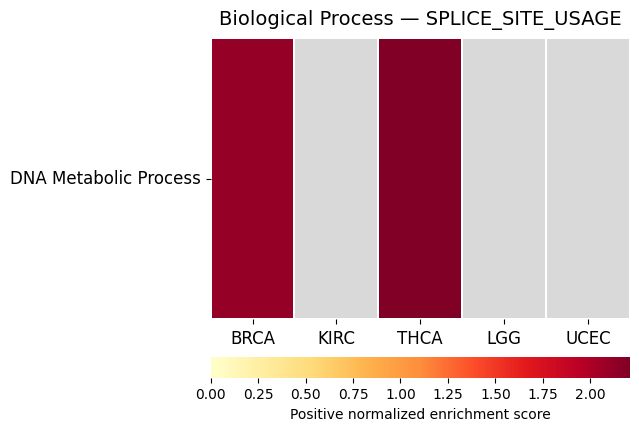

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/shared_positive_gsea_biological_process_splice_site_usage_by_cancer.png


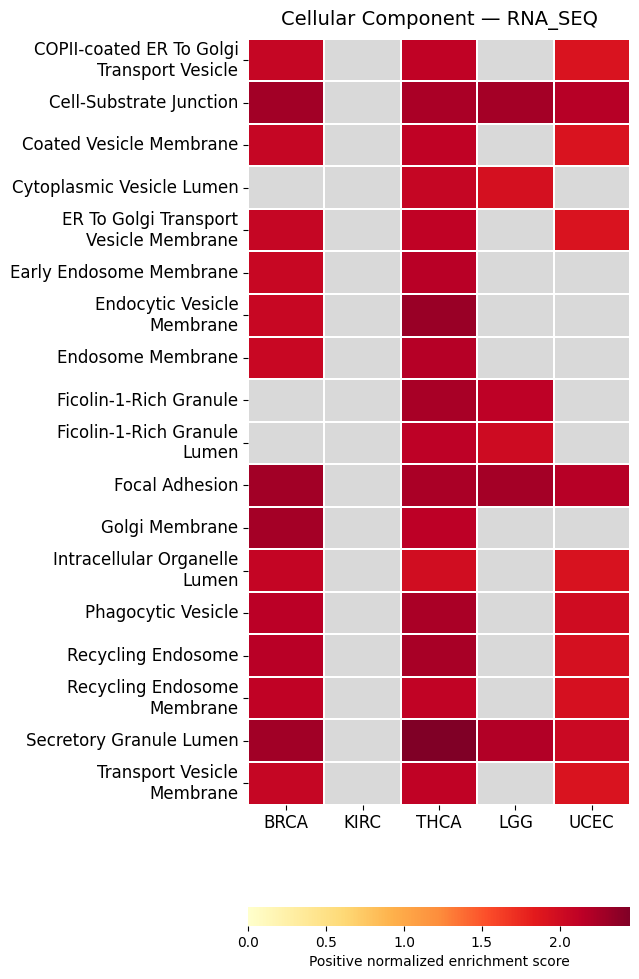

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/shared_positive_gsea_cellular_component_rna_seq_by_cancer.png


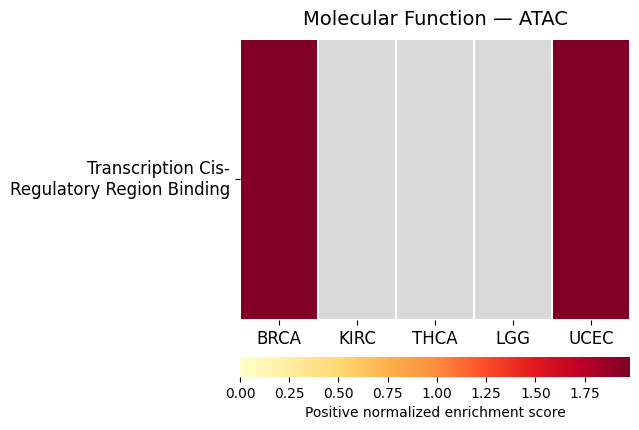

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/shared_positive_gsea_molecular_function_atac_by_cancer.png


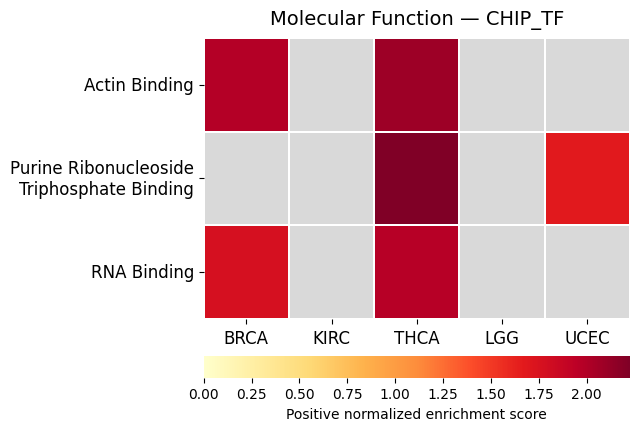

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/shared_positive_gsea_molecular_function_chip_tf_by_cancer.png


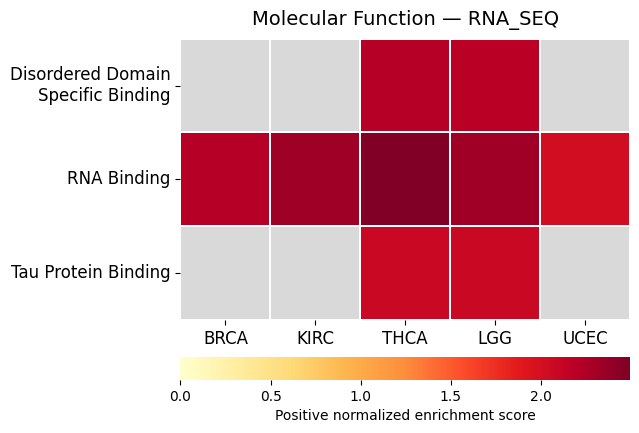

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_gsea_by_cancer_modality/shared_positive_gsea_molecular_function_rna_seq_by_cancer.png


In [5]:
MIN_CANCER_TYPES_PER_TERM = 2

if positive_significant.empty:
    print('No significantly positive GO enrichments were found.')
else:
    shared_term_counts = (
        positive_significant.groupby(['go_category', 'modality', 'Term'])['cancer_type']
        .nunique()
        .rename('n_significant_cancer_types')
        .reset_index()
    )
    shared_terms = shared_term_counts[
        shared_term_counts['n_significant_cancer_types'].ge(MIN_CANCER_TYPES_PER_TERM)
    ]
    shared_positive_significant = positive_significant.merge(
        shared_terms, on=['go_category', 'modality', 'Term'], how='inner'
    )
    if shared_positive_significant.empty:
        print(f'No GO terms were significantly positively enriched in at least {MIN_CANCER_TYPES_PER_TERM} cancer types.')
    else:
        display(shared_positive_significant.sort_values(['go_category', 'modality', 'Term', 'cancer_type']))
        for (go_category, modality), category_results in gsea_results.groupby(['go_category', 'modality']):
            selected_terms = shared_positive_significant.loc[
                shared_positive_significant['go_category'].eq(go_category) & shared_positive_significant['modality'].eq(modality),
                'Term',
            ].unique()
            if not len(selected_terms):
                continue
            heatmap_results = category_results[category_results['Term'].isin(selected_terms)]
            enrichment_df = heatmap_results.pivot_table(index='Term', columns='cancer_type', values='nes', aggfunc='max').reindex(columns=CANCER_TYPES)
            adjusted_p_values = heatmap_results.pivot_table(index='Term', columns='cancer_type', values='bh_adjusted_p_value', aggfunc='min').reindex(columns=CANCER_TYPES)
            mask = adjusted_p_values.ge(GO_FDR_THRESHOLD) | adjusted_p_values.isna() | enrichment_df.le(0)
            fig, ax = plt.subplots(figsize=(max(5, 1.3 * len(CANCER_TYPES)), max(4.5, 0.6 * len(enrichment_df))))
            ax.set_facecolor('#D9D9D9')
            sns.heatmap(enrichment_df, mask=mask, cmap='YlOrRd', vmin=0, linewidths=0.25, linecolor='white', cbar_kws={'label': 'Positive normalized enrichment score', 'orientation': 'horizontal', 'pad': 0.1}, ax=ax)
            ax.set_yticklabels([fill(term.split(' (')[0], width=25) for term in enrichment_df.index], rotation=0, fontsize=12)
            plt.xticks(fontsize=12)
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_title(f'{go_category} — {modality}', fontsize=14, pad=10)
            fig.tight_layout()
            output_name = 'shared_positive_gsea_' + go_category.lower().replace(' ', '_') + '_' + modality.lower() + '_by_cancer.png'
            output_plot = OUTPUT_DIR / output_name
            fig.savefig(output_plot, dpi=300, bbox_inches='tight')
            plt.show()
            print(output_plot)